# Linear Regression
This is one of the most basic algorithms in ML, that tries to fit a line using the data features to the data observations.

$$\hat y= w_1x_1+w_2x_2+....+w_nx_n+b$$

- $w_1.....w_n$ -> weights of each feature of the dataset
- $b$ -> bias term

The model assumes that the independent variables(features) has some kind linear relationship with  each other and errors of prediction at each data point should be independent of each other.\
Also tthe correlation between data should not be very high

To get a line that fits very closely to the data observations, we need to find the w's and b's so that the difference between the prediction and actual values of data is small.

The error metric we want to reduce here is the Mean Squared Error:
$$\frac{1}{n} \sum_{i=1}^{n} (\hat y_i-y_i)^2$$

which allows for penalising higher error heavily


## Gradient Descent for Linear Regression

To find the optimal values of the weight ($w$) and bias ($b$) that best fit a line to the data, we use an optimization algorithm called gradient descent. The purpose of this algorithm is to iteratively adjust the parameters so that the prediction error is minimized.

Take for example linear regression with one variable, whose prediction function is:

$$
\hat{y} = wx + b
$$

To measure how well the model fits the data, we use the Mean Squared Error as the cost function:

$$
J(w, b) = \frac{1}{2m} \sum_{i=1}^{m} \left( f_{w,b}(x^{(i)}) - y^{(i)} \right)^2
$$

- $m$ is the number of training examples  
- $f_{w,b}(x^{(i)}) = wx^{(i)} + b$ is the predicted value  
- $y^{(i)}$ is the actual value  

The factor $\frac{1}{2}$ is included for mathematical convenience, as it simplifies the derivative expressions.

To minimize the cost, we compute the partial derivatives of $J(w, b)$ with respect to $w$ and $b$. These derivatives indicate how the cost changes with small changes in the parameters.

$$
\frac{\partial J(w, b)}{\partial w} = \frac{1}{m} \sum_{i=1}^{m} \left( (wx^{(i)} + b) - y^{(i)} \right) x^{(i)}
$$

$$
\frac{\partial J(w, b)}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} \left( (wx^{(i)} + b) - y^{(i)} \right)
$$

The gradient provides both the **direction** and **magnitude** of change required to reduce the cost.

- If the prediction is higher than the actual value, the error is positive, leading to a positive gradient → parameters should be decreased  
- If the prediction is lower than the actual value, the error is negative → parameters should be increased  

The parameters are updated by moving in the opposite direction of the gradient:

$$
w := w - \alpha \frac{\partial J}{\partial w}
$$

$$
b := b - \alpha \frac{\partial J}{\partial b}
$$

The learning rate $\alpha$ controls the step size, i.e., how much the parameters are updated in the direction of the gradient at each step. Smaller values of $\alpha$ lead to slower convergence towards the minimum loss, while larger values may cause the updates to overshoot the minimum loss or become unstable.

The algorithm starts by initializing $w$ and $b$, and then repeatedly performs the following steps:

- compute predictions using the current parameters  
- measure the cost (error)  
- compute the gradients  
- update the parameters  

This iterative process continues until the change in the cost becomes very small or the parameters stabilize, indicating that the model has reached (or very close to) the minimum.

In [94]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor as SGD, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

housedata = fetch_california_housing()
X = housedata.data
y = housedata.target


Mean Squared Error: 0.7104348108622902
R^2 Score: 0.45785260734707267


Text(0, 0.5, 'House Value')

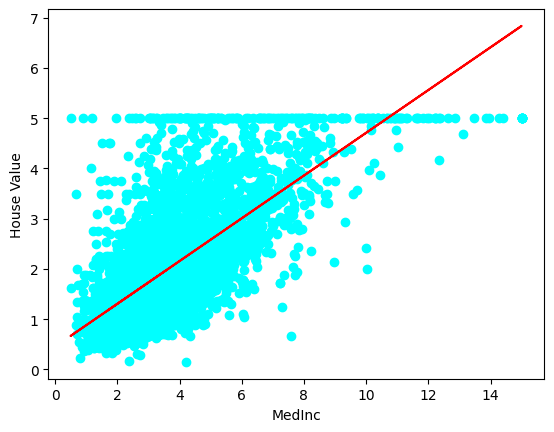

In [95]:
import matplotlib.pyplot as plt

X_tr, X_test, y_tr, y_test = train_test_split(X[:,0].reshape(-1,1), y, test_size=0.2, random_state=42)
LinearReg=SGD()
LinearReg.fit(X_tr, y_tr)
y_pred=LinearReg.predict(X_test)
mse=mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R^2 Score:", r2_score(y_test, y_pred))
plt.scatter(X_test, y_test, color='cyan', label='Actual')
plt.plot(X_test, y_pred, color='red', label='Predicted')
plt.xlabel('MedInc')
plt.ylabel('House Value')

In [96]:
from sklearn.preprocessing import StandardScaler
X_tr, X_test, y_tr, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_tr)

X_test_scaled = scaler.transform(X_test) 

linear_reg = SGD(max_iter=1000, tol=1e-3, random_state=42)


linear_reg.fit(X_train_scaled, y_tr)

y_pred = linear_reg.predict(X_test_scaled)

mse=mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R^2 Score:", r2_score(y_test, y_pred))
residuals = y_test - y_pred


Mean Squared Error: 0.5505987775857769
R^2 Score: 0.5798267665069696


## LinearRegression (sklearn implementation)

In practice, the `LinearRegression` class in sklearn does not use gradient descent.  
Instead, it computes the optimal parameters directly using a closed-form solution based on linear algebra.

The solution is given by:

$$
w = (X^T X)^{-1} X^T y
$$

This method directly finds the values of weights that minimize the mean squared error.
It is efficient for small to medium-sized datasets  

In both cases, the final model remains the same:

$$
\hat{y} = w^T x + b
$$

In [97]:

X_tr, X_test, y_tr, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_tr)

X_test_scaled = scaler.transform(X_test) 

linear_reg = LinearRegression()


linear_reg.fit(X_train_scaled, y_tr)

y_pred = linear_reg.predict(X_test_scaled)

mse=mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R^2 Score:", r2_score(y_test, y_pred))
residuals = y_test - y_pred


Mean Squared Error: 0.5558915986952442
R^2 Score: 0.575787706032451


## Some Linear Regression variants 

For all regularised variants, the prediction remains:

$$
\hat{y} = w^T x + b
$$


### Lasso Regression (L1 Regularization)

Lasso regression adds an L1 penalty to the loss function.

$$
J(w, b) = \frac{1}{2m} \sum_{i=1}^{m} (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{n} |w_j|
$$

- $\lambda$ controls the strength of regularization  
- the term $\sum |w_j|$ penalizes the absolute values of the weights  

L1 regularization encourages sparsity in the model, meaning some coefficients become exactly zero.  
As a result, less important or irrelevant features are automatically removed from the model.

This makes Lasso suited for feature selection, especially in datasets with a large number of features.


In [98]:
from sklearn.linear_model import Lasso
X_tr, X_test, y_tr, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
Lasso=Lasso(alpha=0.1)
Lasso.fit(X_tr, y_tr)
y_pred_lasso=Lasso.predict(X_test)
mse_lasso=mean_squared_error(y_test, y_pred_lasso)
r2_score_lasso = r2_score(y_test, y_pred_lasso)
print("Lasso Regression Mean Squared Error:", mse_lasso)
print("Lasso Regression R^2 Score:", r2_score_lasso)

Lasso Regression Mean Squared Error: 0.6135115198058131
Lasso Regression R^2 Score: 0.5318167610318159


In [102]:
#LassoCV automatically tunes the alpha parameter using cross-validation to find the best value for regularization.
from sklearn.linear_model import LassoCV
LassoCV=LassoCV(alphas=[0.01, 0.1, 1, 10], cv=5)
LassoCV.fit(X_tr, y_tr)
y_pred_lasso_cv=LassoCV.predict(X_test)
mse_lasso_cv=mean_squared_error(y_test, y_pred_lasso_cv)
r2_score_lasso_cv = r2_score(y_test, y_pred_lasso_cv)
print("Mean Squared Error:", mse_lasso_cv)
print("R^2 Score:", r2_score_lasso_cv)


Mean Squared Error: 0.544449158124652
R^2 Score: 0.5845196673976367




### Ridge Regression 

Ridge regression adds an L2 penalty to the loss function.

$$
J(w, b) = \frac{1}{2m} \sum_{i=1}^{m} (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{n} w_j^2
$$

- $\lambda$ controls the amount of shrinkage  
- the term $\sum w_j^2$ penalizes large weights  

The L2 penalty shrinks coefficients toward zero but does not make them exactly zero.  
This helps reduce model variance and prevents overfitting.

Ridge regression is especially useful when features are correlated, as it distributes the weights more smoothly across them.




In [99]:
from sklearn.linear_model import Ridge
X_tr, X_test, y_tr, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
RidgeReg=Ridge(alpha=4.2)
RidgeReg.fit(X_tr, y_tr)

y_pred_ridge=RidgeReg.predict(X_test)
mse_ridge=mean_squared_error(y_test, y_pred_ridge)
r2_score_ridge = r2_score(y_test, y_pred_ridge)
print(" Mean Squared Error:", mse_ridge)
print(" R^2 Score:", r2_score_ridge)


 Mean Squared Error: 0.555526047586188
 R^2 Score: 0.576066665590212


In [101]:
# RidgeCV with cross-validation to find the best alpha
from sklearn.linear_model import RidgeCV
X_tr, X_test, y_tr, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
alphas = [0.1, 1.0, 10.0, 100.0]
RidgeCVReg=RidgeCV(alphas=alphas, cv=5)
RidgeCVReg.fit(X_tr, y_tr)
y_pred_ridgecv=RidgeCVReg.predict(X_test)
mse_ridgecv=mean_squared_error(y_test, y_pred_ridgecv)
r2_score_ridgecv = r2_score(y_test, y_pred_ridgecv)
print("Mean Squared Error:", mse_ridgecv)
print("Regression R^2 Score:", r2_score_ridgecv)

Mean Squared Error: 0.5550405537342997
Regression R^2 Score: 0.5764371559180026



### Elastic Net 

Elastic Net combines both L1 and L2 regularization penalties:

$$
J(w, b) = \frac{1}{2m} \sum_{i=1}^{m} (y_i - \hat{y}_i)^2 
+ \lambda_1 \sum_{j=1}^{n} |w_j| 
+ \lambda_2 \sum_{j=1}^{n} w_j^2
$$

It is particularly useful when:

- there are many features  
- features are highly correlated  

In [61]:
from sklearn.linear_model import ElasticNet
Elastic=ElasticNet(alpha=0.5, l1_ratio=0.5,)
Elastic.fit(X_tr, y_tr)
y_pred_elastic=Elastic.predict(X_test)
mse_elastic=mean_squared_error(y_test, y_pred_elastic)
r2_score_elastic = r2_score(y_test, y_pred_elastic)
print("Elastic Net Regression Mean Squared Error:", mse_elastic)
print("Elastic Net Regression R^2 Score:", r2_score_elastic)

Elastic Net Regression Mean Squared Error: 0.6868730783041608
Elastic Net Regression R^2 Score: 0.4758330492925781


In [ ]:
# ElasticNetCV with cross-validation to find the best alpha and l1_ratio
from sklearn.linear_model import ElasticNetCV
ElasticNetCV=ElasticNetCV(alphas=[0.01, 0.1, 1, 10], l1_ratio=[0.2, 0.5, 0.8], cv=5)
ElasticNetCV.fit(X_tr, y_tr)
y_pred_elastic_cv=ElasticNetCV.predict(X_test)
mse_elastic_cv=mean_squared_error(y_test, y_pred_elastic_cv)
r2_score_elastic_cv = r2_score(y_test, y_pred_elastic_cv)
print("Mean Squared Error:", mse_elastic_cv)
print("R^2 Score:", r2_score_elastic_cv)


Mean Squared Error: 0.5467199202266105
R^2 Score: 0.5827868022084751



### Polynomial Regression 

Polynomial regression extends linear regression by allowing the model to capture non-linear relationships between features and the target.

Even though the relationship becomes non-linear in terms of input features, the model is still linear in terms of parameters.

For example, for a single feature $x$, we create:

$$
x, \; x^2, \; x^3, \dots
$$

The prediction function then becomes:

$$
\hat{y} = w_0 + w_1 x + w_2 x^2 + \dots + w_d x^d
$$


Mean Squared Error: 0.6981042443894434
R^2 Score: 0.46726231582556577


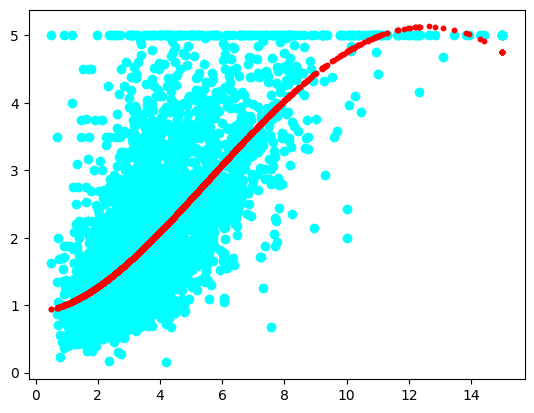

In [38]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
X_tr, X_test, y_tr, y_test = train_test_split(X[:,0].reshape(-1,1), y, test_size=0.2, random_state=42)
degree = 4

model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
model.fit(X_tr, y_tr)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R^2 Score:", r2_score(y_test, y_pred))
plt.scatter(X_test, y_test, color='cyan', label='Actual')
plt.scatter(X_test, y_pred, color='red', s=10, label='Predicted')

# Docs

https://scikit-learn.org/stable/api/sklearn.linear_model.html